In [61]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data

plt.style.use('fivethirtyeight')
%matplotlib inline

In [105]:
import yfinance as yf
import datetime as dt


stock = "POWERGRID.NS"
start = dt.datetime(2000,1,1)
end = dt.datetime(2026,5,20)

df = yf.download(stock,start,end).reset_index()


[*********************100%***********************]  1 of 1 completed


In [106]:
# # df = df.rename(columns={'Unnamed: 0': 'Date'})
# df.columns.values[-1] = 'Date'
# df.columns = df.columns.get_level_values(0)
df = df.rename(columns={'index': 'Date'})


In [107]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
0,2007-10-05,30.896236,33.629602,25.536998,27.579345,855215656
1,2007-10-08,29.314575,31.940448,29.130303,31.940448,126671715
2,2007-10-09,31.310844,31.587251,27.748257,29.329922,116725709
3,2007-10-10,31.602604,32.247556,31.326197,32.124707,67931378
4,2007-10-11,35.134487,36.854358,31.326205,36.854358,106320954


In [119]:
df.columns.tolist()

[('Date', ''),
 ('Close', 'POWERGRID.NS'),
 ('High', 'POWERGRID.NS'),
 ('Low', 'POWERGRID.NS'),
 ('Open', 'POWERGRID.NS'),
 ('Volume', 'POWERGRID.NS')]

In [123]:
df.to_csv("powergrid.csv")
dft = pd.read_csv("powergrid.csv")

In [129]:
dft.head()

,Price,Date,Close,High,Low,Open,Volume
0,Ticker,NaN,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
1,0,2007-10-05,30.896236419677734,33.62960189509571,25.536998153531204,27.579344583114715,855215656
2,1,2007-10-08,29.3145751953125,31.94044832271491,29.130302593015134,31.94044832271491,126671715
3,2,2007-10-09,31.31084442138672,31.58725116900844,27.74825699210877,29.329921759876378,116725709
4,3,2007-10-10,31.602603912353516,32.24755569269947,31.32619719665519,32.12470664355446,67931378


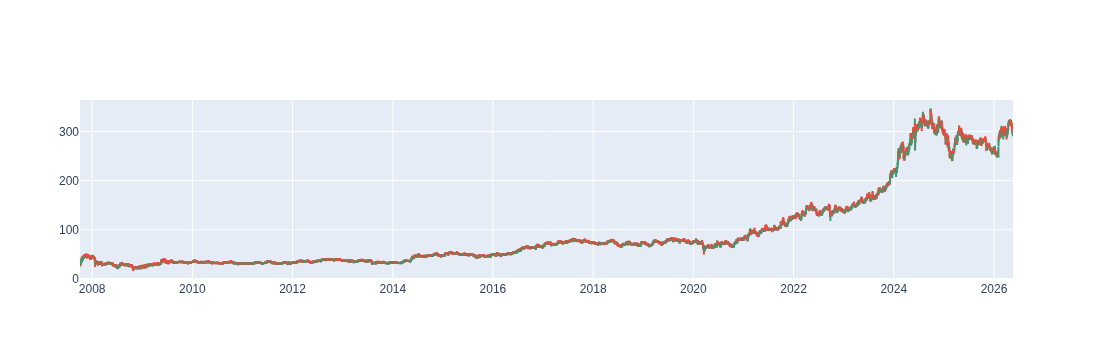

In [131]:
# CandleSticks
import plotly.graph_objects as go 

fig = go.Figure(data=[go.Candlestick(
    x=dft['Date'],
    open=dft['Open'],
    high=dft['High'],
    low=dft['Low'],
    close=dft['Close']
)])

fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()


In [133]:
dft.drop('Date', axis = 1)

,Price,Close,High,Low,Open,Volume
0,Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
1,0,30.896236419677734,33.62960189509571,25.536998153531204,27.579344583114715,855215656
2,1,29.3145751953125,31.94044832271491,29.130302593015134,31.94044832271491,126671715
3,2,31.31084442138672,31.58725116900844,27.74825699210877,29.329921759876378,116725709
4,3,31.602603912353516,32.24755569269947,31.32619719665519,32.12470664355446,67931378
...,...,...,...,...,...,...
4586,4585,301.5,305.3999938964844,295.6499938964844,304.25,23775882
4587,4586,301.75,307.54998779296875,300.6000061035156,306.0,14012601
4588,4587,305.8500061035156,308.1499938964844,302.8999938964844,307.79998779296875,10092811
4589,4588,296.54998779296875,298.45001220703125,290.20001220703125,296.29998779296875,16036198


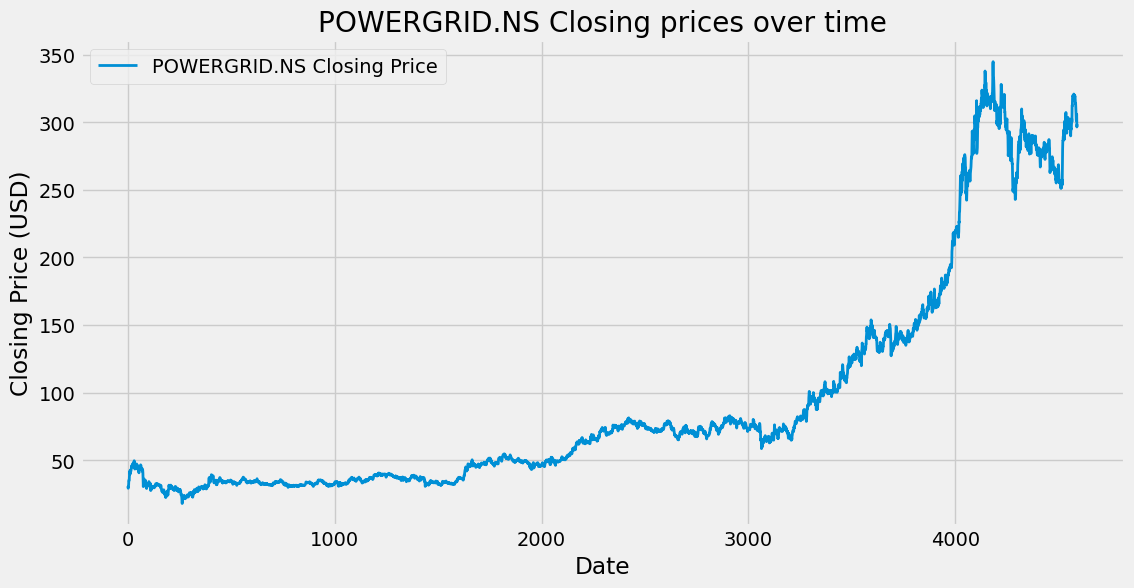

In [135]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label = f'{stock} Closing Price', linewidth = 2)
plt.title(f'{stock} Closing prices over time')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.show()

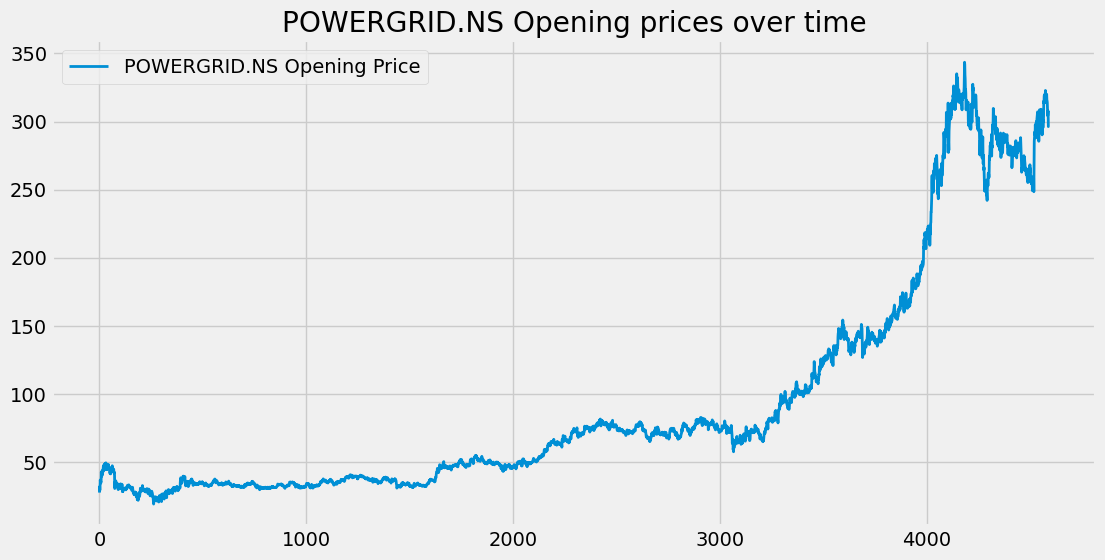

In [136]:
plt.figure(figsize=(12, 6))
plt.plot(df['Open'], label = f'{stock} Opening Price', linewidth = 2)
plt.title(f'{stock} Opening prices over time')
plt.legend()
plt.show()

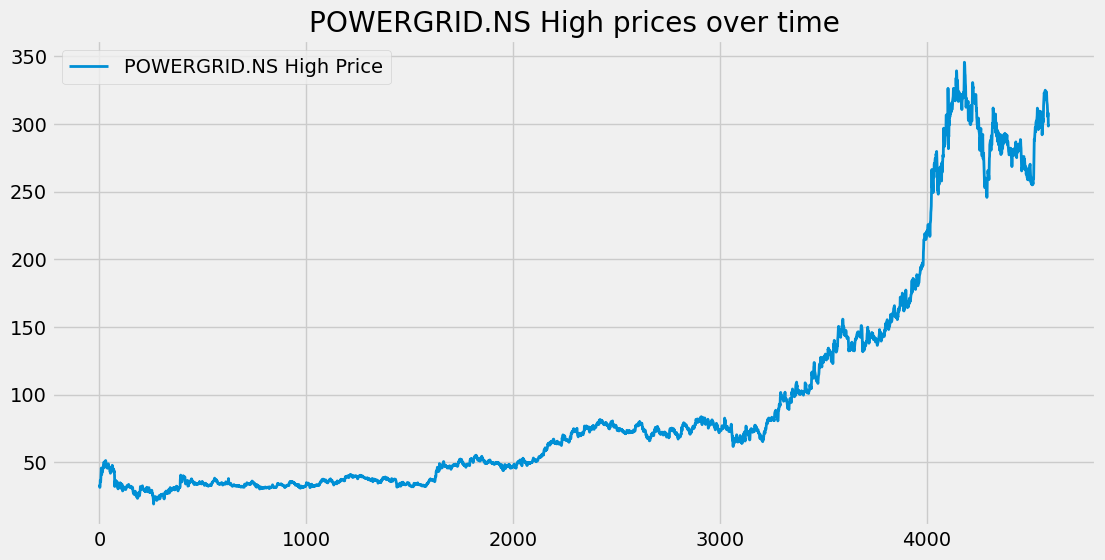

In [137]:
plt.figure(figsize=(12, 6))
plt.plot(df['High'], label = f'{stock} High Price', linewidth = 2)
plt.title(f'{stock} High prices over time')
plt.legend()
plt.show()

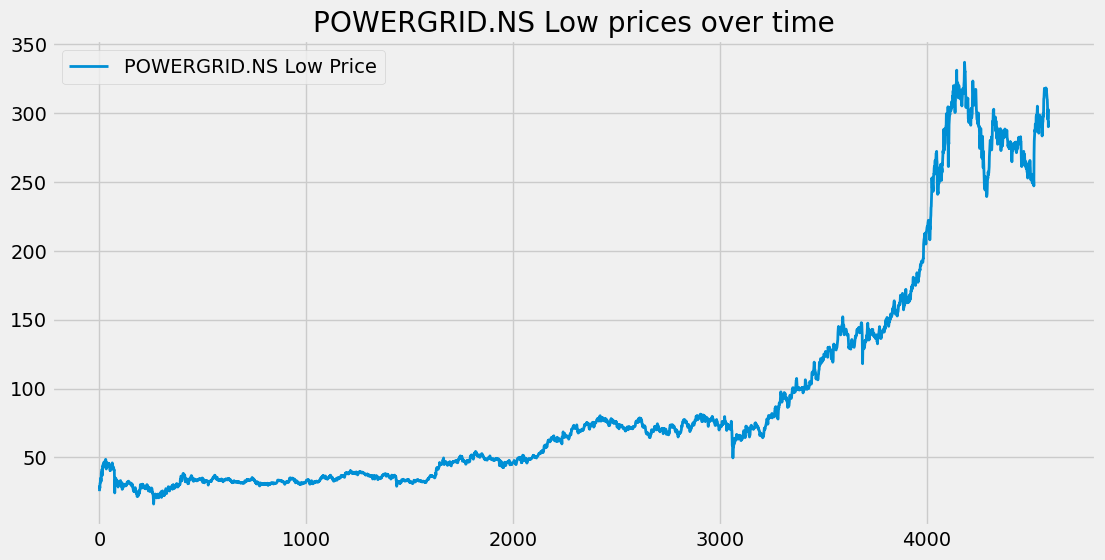

In [138]:
plt.figure(figsize=(12, 6))
plt.plot(df['Low'], label = f'{stock} Low Price', linewidth = 2)
plt.title(f'{stock} Low prices over time')
plt.legend()
plt.show()

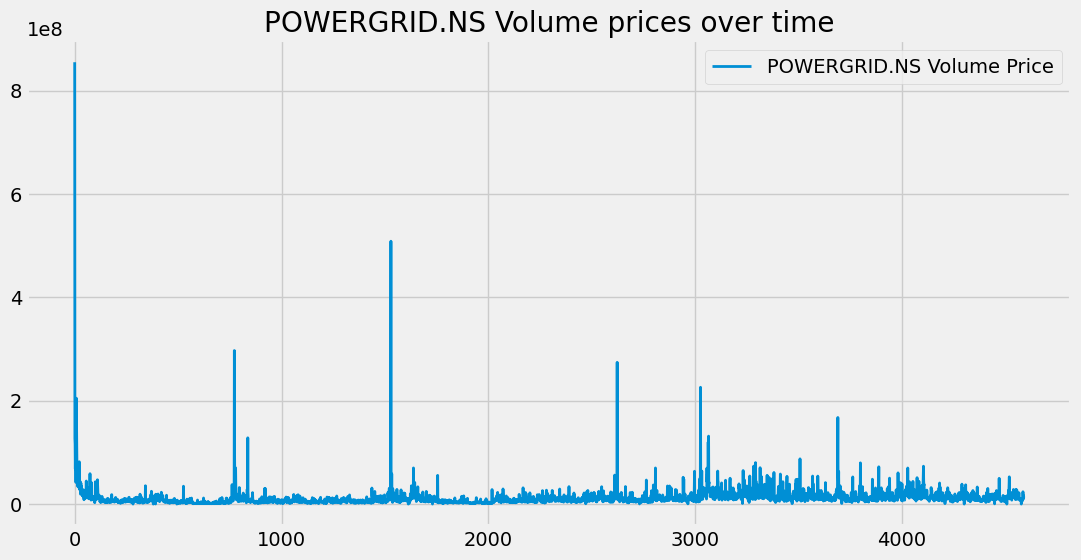

In [139]:
plt.figure(figsize=(12, 6))
plt.plot(df['Volume'], label = f'{stock} Volume Price', linewidth = 2)
plt.title(f'{stock} Volume prices over time')
plt.legend()
plt.show()

In [144]:
ma100 = df.Close.rolling(100).mean()
# .Close: Selects only the column containing the final daily closing prices
# .rolling(100): Groups the data into a sliding window of 100 consecutive days.
# .mean(): Calculates the mathematical average of the 100 days inside that window.

In [146]:
ma200 = df.Close.rolling(200).mean()


In [147]:
ma100

Ticker,POWERGRID.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4585,288.120571
4586,288.563473
4587,289.039960
4588,289.454596


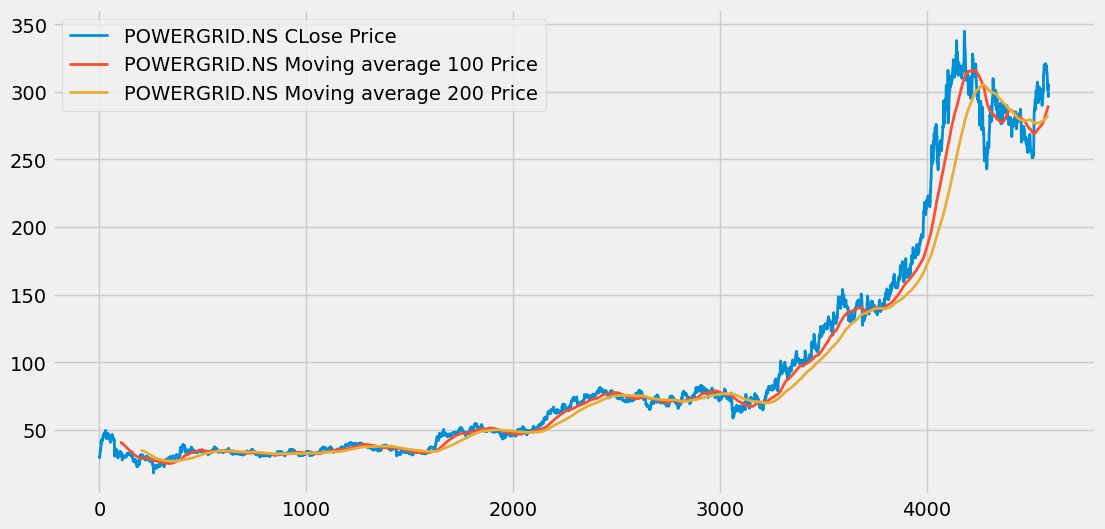

In [151]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} CLose Price', linewidth = 2)
plt.plot(ma100, label = f'{stock} Moving average 100 Price', linewidth = 2)
plt.plot(ma200, label = f'{stock} Moving average 200 Price', linewidth = 2)
plt.legend()
plt.show()

In [156]:
ema100 = df.Close.ewm(span=100,adjust=False).mean()
ema200 = df.Close.ewm(span=200,adjust=False).mean()

# ewm(Exponential Weighted Moving) : Exponential moving average  


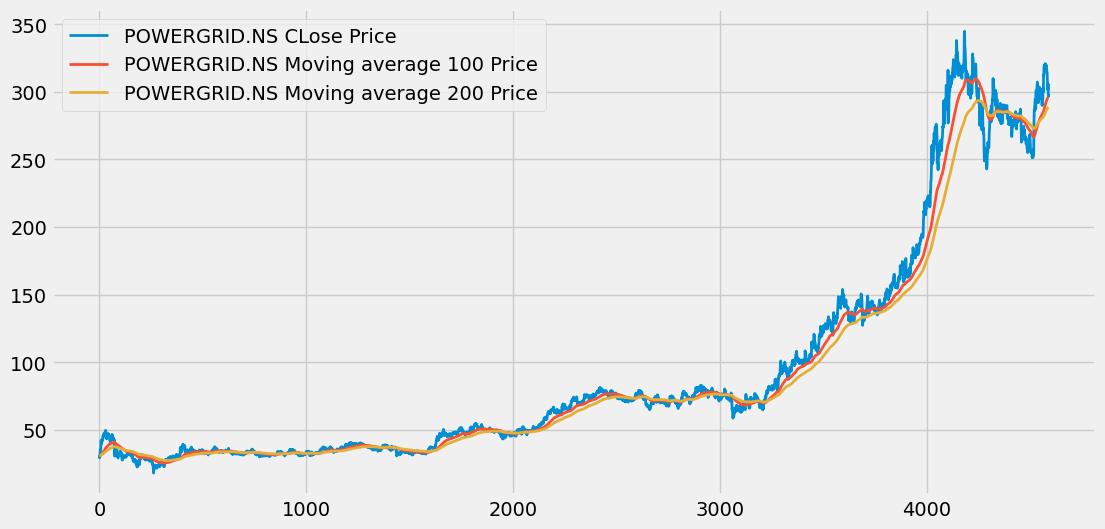

In [158]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} CLose Price', linewidth = 2)
plt.plot(ema100, label = f'{stock} Exp. Moving average 100 Price', linewidth = 2)
plt.plot(ema200, label = f'{stock} Exp. Moving average 200 Price', linewidth = 2)
plt.legend()
plt.show()

In [160]:
# RNN: Only remembers what happened in the last few days. It cannot connect a market crash from three months ago to today's market behavior.
# LSTM: Uses a "Cell State" (an internal memory conveyor belt) to preserve crucial historical data across hundreds of days without losing structural signal strength

In [164]:
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Open'][0:int(len(df)*0.70):int(len(df))])

In [166]:
data_training.shape

(3213, 1)

In [171]:
data_testing.shape


(1, 1)

In [173]:
from sklearn.preprocessing import MinMaxScaler
scalar = MinMaxScaler(feature_range = (0,1))